In [115]:
# === Core objects ===
pca_loadings = pd.read_parquet("results/pca/pca_loadings.parquet")
mapping = pd.read_csv("data/processed/ensg_to_symbol.csv")
expr_symbol = pd.read_parquet("data/processed/expr_logcpm_symbol.parquet")
metadata = pd.read_csv("data/processed/metadata_samples.csv", index_col=0)

In [116]:
# Cell 0: Setup project path so analysis_utils is recognized
from pathlib import Path
import sys, os

# Adjust if your path differs
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis").resolve()
PROJECT_ROOT = Path(
    os.environ.get(
        "CRISPR_CART_ROOT",
        "/Users/acastano/Desktop/crispr_carT_AI_analysis"
    )
).resolve()
# 1) Make Jupyter "stand" in the project root
os.chdir(PROJECT_ROOT)
print("CWD:", Path.cwd())

# 2) Make Python able to import your package
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Sanity checks
print("analysis_utils exists:", (PROJECT_ROOT / "analysis_utils").exists())
print("analysis_utils/__init__.py exists:", (PROJECT_ROOT / "analysis_utils" / "__init__.py").exists())


CWD: /Users/acastano/Desktop/crispr_carT_AI_analysis
analysis_utils exists: True
analysis_utils/__init__.py exists: True


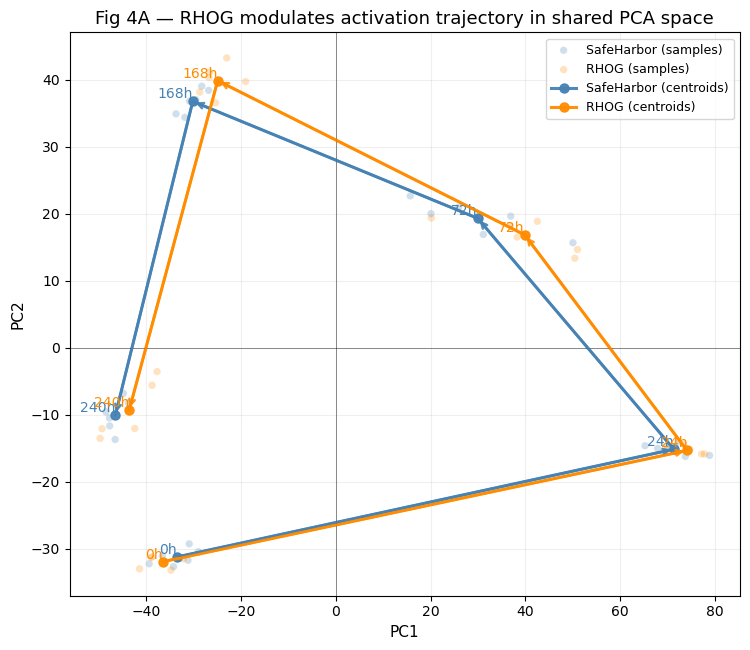

Saved: figures/fig4_rhog_synthesis/Fig4A_PCA_trajectory_PC1_PC2_RHOG_vs_SafeHarbor.png


In [117]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load metadata with PCs (adjust path if needed)
# -----------------------------
# Typical file you already generate:
# meta_pca = pd.read_csv("results/modules/metadata_with_pcs.csv", index_col=0)

meta_pca = pd.read_csv("results/modules/metadata_with_pcs.csv", index_col=0)

# -----------------------------
# Choose PCA axes (PC1/PC2 OR PC5/PC6)
# -----------------------------
PCX, PCY = "PC1", "PC2"   # <-- change to ("PC5","PC6") if that's your chosen space

required = {PCX, PCY, "guide", "hours"}
missing = required - set(meta_pca.columns)
if missing:
    raise ValueError(f"meta_pca missing columns: {missing}")

# Keep only the two conditions we care about
meta_pca = meta_pca[meta_pca["guide"].isin(["SafeHarbor", "RHOG"])].copy()

# Ensure numeric hours + sorted
meta_pca["hours"] = pd.to_numeric(meta_pca["hours"], errors="coerce")
meta_pca = meta_pca.dropna(subset=["hours", PCX, PCY])

# -----------------------------
# Style
# -----------------------------
colors = {"SafeHarbor": "steelblue", "RHOG": "darkorange"}

fig, ax = plt.subplots(figsize=(7.6, 6.6))

# Background points (replicates)
for g in ["SafeHarbor", "RHOG"]:
    df_g = meta_pca[meta_pca["guide"] == g]
    ax.scatter(
        df_g[PCX], df_g[PCY],
        s=28, alpha=0.25,
        c=colors[g], edgecolor="none",
        label=f"{g} (samples)"
    )

# Centroids + arrows
for g in ["SafeHarbor", "RHOG"]:
    df_g = meta_pca[meta_pca["guide"] == g]

    cent = (
        df_g.groupby("hours")[[PCX, PCY]]
        .mean()
        .reset_index()
        .sort_values("hours")
    )

    # Trajectory line + centroid markers
    ax.plot(
        cent[PCX], cent[PCY],
        "-o", linewidth=2.2, markersize=6.5,
        color=colors[g], alpha=0.95,
        label=f"{g} (centroids)"
    )

    # Arrows between consecutive centroids
    for i in range(len(cent) - 1):
        x0, y0 = cent.loc[cent.index[i], [PCX, PCY]]
        x1, y1 = cent.loc[cent.index[i+1], [PCX, PCY]]
        ax.annotate(
            "", xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", lw=1.8, color=colors[g], alpha=0.9)
        )

    # Hour labels at centroid points
    for _, r in cent.iterrows():
        ax.text(
            r[PCX], r[PCY],
            f"{int(r['hours'])}h",
            fontsize=10, color=colors[g],
            ha="right", va="bottom"
        )

# Reference lines (optional — keep if your PCA is centered)
ax.axvline(0, color="black", lw=0.6, alpha=0.5)
ax.axhline(0, color="black", lw=0.6, alpha=0.5)

# Labels
ax.set_title("Fig 4A — RHOG modulates activation trajectory in shared PCA space", fontsize=13)
ax.set_xlabel(PCX, fontsize=11)
ax.set_ylabel(PCY, fontsize=11)

ax.grid(alpha=0.2)

# Clean legend (avoid duplicates)
handles, labels = ax.get_legend_handles_labels()
# keep only one entry per label (order-preserving)
seen = set()
uniq = []
for h, l in zip(handles, labels):
    if l not in seen:
        uniq.append((h, l))
        seen.add(l)
ax.legend([h for h, _ in uniq], [l for _, l in uniq], frameon=True, fontsize=9, loc="best")

fig.tight_layout()

# -----------------------------
# Save
# -----------------------------
outdir = Path("figures/fig4_rhog_synthesis")
outdir.mkdir(parents=True, exist_ok=True)

stem = f"Fig4A_PCA_trajectory_{PCX}_{PCY}_RHOG_vs_SafeHarbor"
fig.savefig(outdir / f"{stem}.png", dpi=300, bbox_inches="tight")
fig.savefig(outdir / f"{stem}.pdf", bbox_inches="tight")

plt.show()

print("Saved:", outdir / f"{stem}.png")

In [118]:
import os

for root, dirs, files in os.walk("results"):
    for f in files:
        if "metadata_with_pcs" in f:
            print(os.path.join(root, f))
            

results/modules/metadata_with_pcs.csv
results/modules/metadata_with_pcs.parquet
results/modules/.ipynb_checkpoints/metadata_with_pcs-checkpoint.csv


In [119]:
meta_pca.groupby(["guide", "hours"]).size()

guide       hours
RHOG        0        6
            24       6
            72       6
            168      6
            240      6
SafeHarbor  0        6
            24       6
            72       6
            168      6
            240      6
dtype: int64

In [120]:
import pandas as pd

expr_symbol = pd.read_parquet("data/processed/expr_logcpm_symbol.parquet")
metadata    = pd.read_csv("data/processed/metadata_samples.csv", index_col=0)

expr_symbol.shape

(41250, 60)

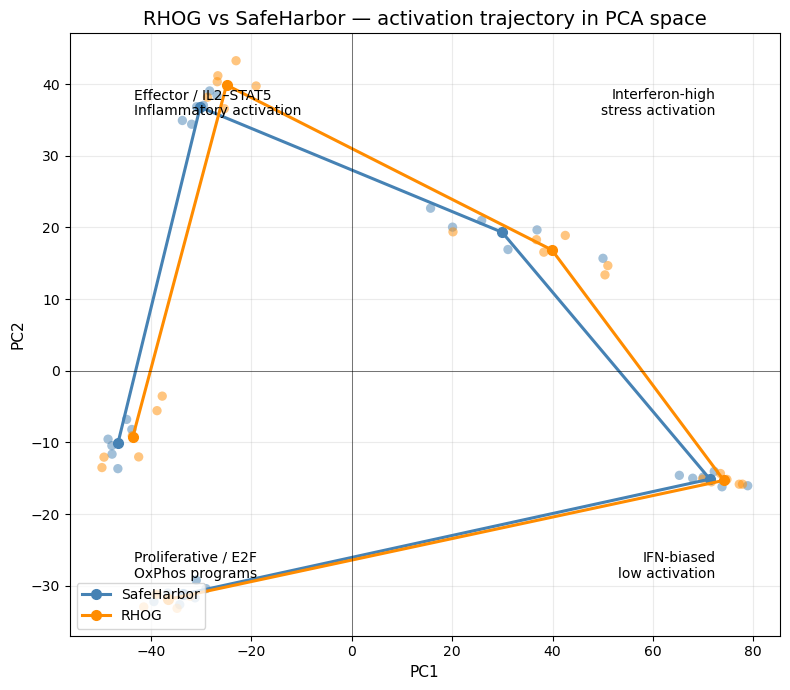

Saved: figures/fig4_RHOG_synthesis/Fig4A_RHOG_vs_SafeHarbor_PCA_trajectory.png


In [121]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Inputs ----------
meta_pca = pd.read_csv("results/modules/metadata_with_pcs.csv", index_col=0)

PCX, PCY = "PC1", "PC2"     # change to ("PC5","PC6") if that's your chosen space
OUTDIR = Path("figures/fig4_RHOG_synthesis")
OUTDIR.mkdir(parents=True, exist_ok=True)
OUTNAME = "Fig4A_RHOG_vs_SafeHarbor_PCA_trajectory.png"

# ---------- Checks ----------
required = {PCX, PCY, "guide", "hours"}
missing = required - set(meta_pca.columns)
if missing:
    raise ValueError(f"metadata_with_pcs.csv is missing columns: {missing}")

# keep only the two guides we care about (in case other guides exist later)
meta = meta_pca[meta_pca["guide"].isin(["SafeHarbor", "RHOG"])].copy()

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8, 7))

color_map = {"SafeHarbor": "steelblue", "RHOG": "darkorange"}

# background points (honest scatter)
for cond in ["SafeHarbor", "RHOG"]:
    m = meta["guide"] == cond
    ax.scatter(
        meta.loc[m, PCX],
        meta.loc[m, PCY],
        s=45,
        alpha=0.5,
        edgecolor="none",
        c=color_map[cond],
        label=None
    )

# centroid trajectories per timepoint
for cond in ["SafeHarbor", "RHOG"]:
    dfc = (
        meta[meta["guide"] == cond]
        .groupby("hours")[[PCX, PCY]]
        .mean()
        .reset_index()
        .sort_values("hours")
    )
    ax.plot(
        dfc[PCX], dfc[PCY],
        "-o",
        linewidth=2.2,
        markersize=7,
        alpha=1.0,
        color=color_map[cond],
        label=cond
    )

# reference lines
ax.axvline(0, color="black", linewidth=0.6, alpha=0.6)
ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)

# quadrant-ish biology labels (optional but useful for reviewers)
x_min, x_max = meta[PCX].min(), meta[PCX].max()
y_min, y_max = meta[PCY].min(), meta[PCY].max()
x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)

ax.text(x_min + x_pad, y_max - y_pad,
        "Effector / IL2–STAT5\nInflammatory activation",
        fontsize=10, ha="left", va="top")

ax.text(x_max - x_pad, y_max - y_pad,
        "Interferon-high\nstress activation",
        fontsize=10, ha="right", va="top")

ax.text(x_min + x_pad, y_min + y_pad,
        "Proliferative / E2F\nOxPhos programs",
        fontsize=10, ha="left", va="bottom")

ax.text(x_max - x_pad, y_min + y_pad,
        "IFN-biased\nlow activation",
        fontsize=10, ha="right", va="bottom")

ax.set_xlabel(f"{PCX}", fontsize=11)
ax.set_ylabel(f"{PCY}", fontsize=11)
ax.set_title("RHOG vs SafeHarbor — activation trajectory in PCA space", fontsize=14)

ax.legend(frameon=True, loc="lower left")
ax.grid(alpha=0.25)

fig.tight_layout()

outpath = OUTDIR / OUTNAME
fig.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- gene sets ---
memory_genes = ["TCF7","LEF1","IL7R","CCR7","LTB","MAL","SELL","NOSIP"]
effector_genes = ["GZMB","PRF1","NKG7","IFNG","GNLY","CTSW","KLRD1"]

# --- keep genes that exist ---
memory_genes  = [g for g in memory_genes if g in expr_symbol.index]
effector_genes = [g for g in effector_genes if g in expr_symbol.index]

# --- z-score genes across samples (so score = relative program activity) ---
Z = expr_symbol.apply(lambda r: (r - r.mean()) / (r.std(ddof=0) + 1e-8), axis=1)

scores = pd.DataFrame(index=expr_symbol.columns)
scores["memory_score"]   = Z.loc[memory_genes].mean(axis=0) if memory_genes else np.nan
scores["effector_score"] = Z.loc[effector_genes].mean(axis=0) if effector_genes else np.nan
scores["mem_minus_eff"]  = scores["memory_score"] - scores["effector_score"]

# merge with metadata
df = scores.join(metadata[["guide","hours","donor"]], how="inner")
df = df[df["guide"].isin(["RHOG","SafeHarbor"])].copy()

df.head(), df.groupby(["guide","hours"]).size()

(                             memory_score  effector_score  mem_minus_eff  \
 CART0077_RNAseq_NgsRun1_001      1.143878       -0.904328       2.048206   
 CART0077_RNAseq_NgsRun1_002      1.239216       -0.995710       2.234926   
 CART0077_RNAseq_NgsRun1_003      1.051654       -0.784199       1.835853   
 CART0077_RNAseq_NgsRun1_004      1.374230       -1.001293       2.375523   
 CART0077_RNAseq_NgsRun1_005      1.219954       -1.274090       2.494043   
 
                                   guide  hours        donor  
 CART0077_RNAseq_NgsRun1_001  SafeHarbor      0  CART0077_D1  
 CART0077_RNAseq_NgsRun1_002        RHOG      0  CART0077_D1  
 CART0077_RNAseq_NgsRun1_003  SafeHarbor      0  CART0077_D2  
 CART0077_RNAseq_NgsRun1_004        RHOG      0  CART0077_D2  
 CART0077_RNAseq_NgsRun1_005  SafeHarbor      0  CART0077_D3  ,
 guide       hours
 RHOG        0        6
             24       6
             72       6
             168      6
             240      6
 SafeHarbor  0    

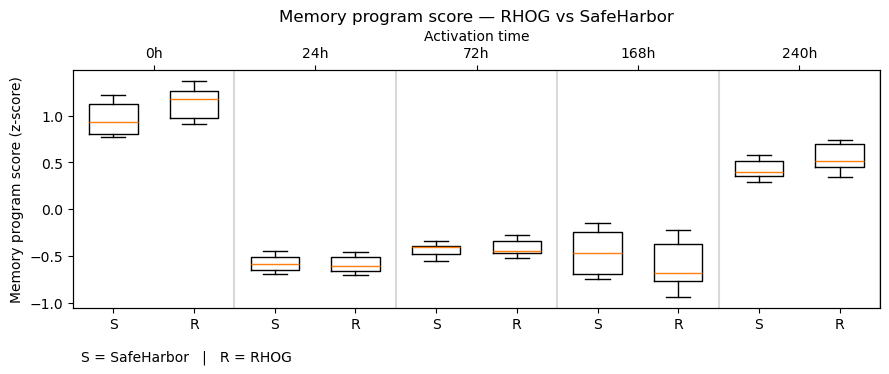

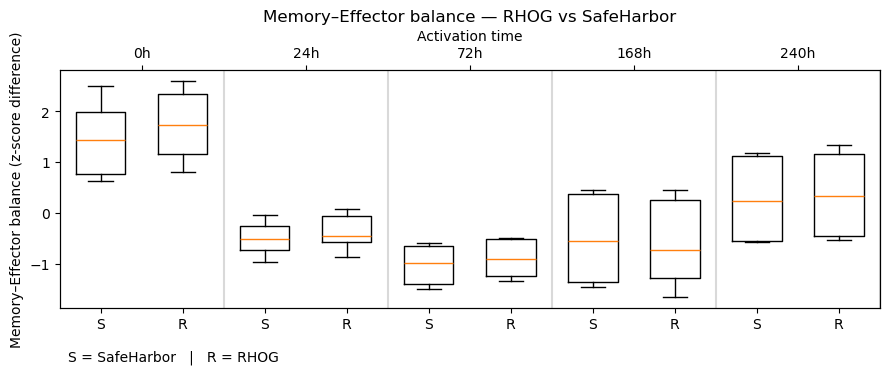

Saved: figures/fig4_rhog_specific/Fig4B1_memory_program_score.png
Saved: figures/fig4_rhog_specific/Fig4B2_memory_minus_effector.png


In [123]:
from pathlib import Path
import matplotlib.pyplot as plt
def box_by_time(df, y_col, y_label, title=""):
    times = sorted(df["hours"].unique())
    fig, ax = plt.subplots(figsize=(9, 4))

    positions, labels = [], []
    pos = 0

    for t in times:
        for g in ["SafeHarbor", "RHOG"]:
            vals = df[(df["hours"] == t) & (df["guide"] == g)][y_col].dropna().values
            ax.boxplot(vals, positions=[pos], widths=0.6, showfliers=False)
            positions.append(pos)
            labels.append("S" if g == "SafeHarbor" else "R")
            pos += 1
        ax.axvline(pos - 0.5, color="k", alpha=0.15)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.text(0.01, -0.22, "S = SafeHarbor   |   R = RHOG", transform=ax.transAxes)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    centers = [i * 2 + 0.5 for i in range(len(times))]
    ax2.set_xticks(centers)
    ax2.set_xticklabels([f"{int(t)}h" for t in times])
    ax2.set_xlabel("Activation time")

    fig.tight_layout()
    return fig, ax

    # top axis with hours
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    centers = [i * 2 + 0.5 for i in range(len(times))]
    ax2.set_xticks(centers)
    ax2.set_xticklabels([f"{int(t)}h" for t in times])
    ax2.set_xlabel("Activation time")

    fig.tight_layout()

    return fig, ax


# --- make and save Fig 4B top panel ---
fig4b_top, _ = box_by_time(
    df,
    y_col="memory_score",
    y_label="Memory program score (z-score)",
    title="Memory program score — RHOG vs SafeHarbor"
)

fig4b_bottom, _ = box_by_time(
    df,
    y_col="mem_minus_eff",
    y_label="Memory–Effector balance (z-score difference)",
    title="Memory–Effector balance — RHOG vs SafeHarbor"
)

OUTDIR = Path("figures/fig4_rhog_specific")
OUTDIR.mkdir(parents=True, exist_ok=True)

fig4b_top.savefig(OUTDIR / "Fig4B1_memory_program_score.png", dpi=300, bbox_inches="tight", facecolor="white")
fig4b_bottom.savefig(OUTDIR / "Fig4B2_memory_minus_effector.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()  # optional: display after saving

plt.close(fig4b_top)
plt.close(fig4b_bottom)

print("Saved:", OUTDIR / "Fig4B1_memory_program_score.png")
print("Saved:", OUTDIR / "Fig4B2_memory_minus_effector.png")

In [124]:
from scipy.stats import ttest_rel

def paired_test_by_time(df, y="memory_score"):
    out = []
    for t in sorted(df["hours"].unique()):
        sub = df[df["hours"]==t].copy()
        wide = sub.pivot_table(index="donor", columns="guide", values=y, aggfunc="mean")
        if {"RHOG","SafeHarbor"}.issubset(wide.columns):
            wide = wide.dropna(subset=["RHOG","SafeHarbor"])
            if len(wide) >= 2:
                stat, p = ttest_rel(wide["RHOG"], wide["SafeHarbor"])
                out.append({"hours": t, "n_donors": len(wide), "mean_delta_R_minus_S": (wide["RHOG"]-wide["SafeHarbor"]).mean(), "p_paired_t": p})
    return pd.DataFrame(out)

paired_test_by_time(df, y="memory_score")

,hours,n_donors,mean_delta_R_minus_S,p_paired_t
0,0,3,0.175003,0.143984
1,24,3,-0.009114,0.267400
2,72,3,0.023517,0.307500
3,168,3,-0.136675,0.184556
4,240,3,0.124294,0.019712


In [125]:
markers = ["TCF7","IL7R","CCR7","LEF1","LTB","SELL","GZMB","PRF1","NKG7","IFNG"]
markers = [g for g in markers if g in expr_symbol.index]

for g in markers:
    tmp = pd.DataFrame({"expr": expr_symbol.loc[g]}).join(metadata[["guide","hours","donor"]])
    tmp = tmp[tmp["guide"].isin(["RHOG","SafeHarbor"])]
    box_by_time(tmp.rename(columns={"expr": g}), y=g, title=f"{g} expression — RHOG vs SafeHarbor")

TypeError: box_by_time() got an unexpected keyword argument 'y'

In [126]:
expr_symbol.shape

(41250, 60)

In [127]:
import pandas as pd

expr_symbol = pd.read_parquet("data/processed/expr_logcpm_symbol.parquet")
metadata    = pd.read_csv("data/processed/metadata_samples.csv", index_col=0)

expr_symbol.shape

(41250, 60)

In [128]:
memory_genes = [
    "IL7R", "CCR7", "TCF7", "LEF1",
    "SELL", "BCL2"
]

effector_genes = [
    "GZMB", "PRF1", "IFNG",
    "NKG7", "GZMK", "TNF"
]

In [129]:
import pandas as pd
import numpy as np

def score_program(expr, genes):
    genes = [g for g in genes if g in expr.index]
    return expr.loc[genes].mean(axis=0)

scores = pd.DataFrame({
    "memory_score":   score_program(expr_symbol, memory_genes),
    "effector_score": score_program(expr_symbol, effector_genes),
}).join(metadata)

/var/folders/qx/x9q1q3ns1hl9156prswwpk5m0000gn/T/ipykernel_19251/1139211677.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


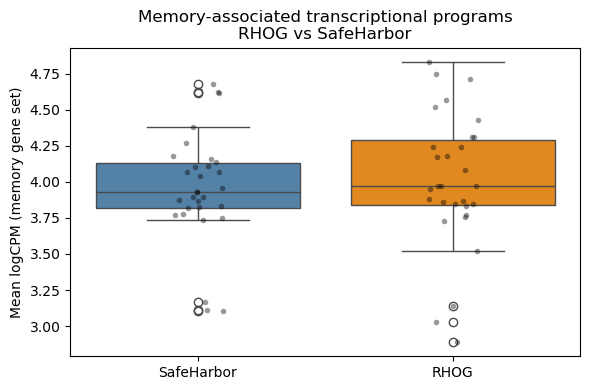

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(
    data=scores,
    x="guide",
    y="memory_score",
    palette={"SafeHarbor": "steelblue", "RHOG": "darkorange"}
)
sns.stripplot(
    data=scores,
    x="guide",
    y="memory_score",
    color="black",
    alpha=0.4,
    size=4
)

plt.title("Memory-associated transcriptional programs\nRHOG vs SafeHarbor")
plt.ylabel("Mean logCPM (memory gene set)")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [131]:
memory_genes = [
    "TCF7", "CCR7", "IL7R", "LEF1", "SELL",
    "BACH2", "MALAT1", "LST1"  # adjust if needed
]

In [132]:
from scipy.stats import mannwhitneyu

sh = df[df["guide"] == "SafeHarbor"]["memory_score"]
rhog = df[df["guide"] == "RHOG"]["memory_score"]

u, p = mannwhitneyu(rhog, sh, alternative="two-sided")
print(p)

1.0


In [133]:
from scipy.stats import mannwhitneyu

for t in sorted(df["hours"].unique()):
    sub = df[df["hours"] == t]
    sh = sub[sub["guide"] == "SafeHarbor"]["memory_score"]
    rh = sub[sub["guide"] == "RHOG"]["memory_score"]
    if len(sh) > 2 and len(rh) > 2:
        _, p = mannwhitneyu(rh, sh, alternative="two-sided")
        print(f"{t}h: p = {p:.3g}")

0h: p = 0.132
24h: p = 0.818
72h: p = 0.937
168h: p = 0.394
240h: p = 0.24


In [134]:
import statsmodels.formula.api as smf

model = smf.ols(
    "memory_score ~ guide + hours",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           memory_score   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.031
Method:                 Least Squares   F-statistic:                    0.1088
Date:                Sat, 20 Dec 2025   Prob (F-statistic):              0.897
Time:                        18:32:45   Log-Likelihood:                -61.689
No. Observations:                  60   AIC:                             129.4
Df Residuals:                      57   BIC:                             135.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0600    

In [135]:
model = smf.mixedlm(
    "memory_score ~ guide + hours",
    data=df,
    groups=df["donor"]
).fit()

/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/acastano/miniconda3/envs/crispr_carT_env/lib/python3.10/site-packa

In [136]:
meta_pca.groupby("guide")[["PC4", "PC5"]].describe()

PC4                                                       \
           count      mean        std        min        25%       50%   
guide                                                                   
RHOG        30.0 -0.628426  13.487220 -18.723551 -12.746776 -3.130835   
SafeHarbor  30.0  0.628426  12.921351 -14.182399 -11.662265 -1.404685   

                                   PC5                                  \
                  75%        max count      mean        std        min   
guide                                                                    
RHOG        10.815614  23.425060  30.0 -0.461412  12.109526 -22.420565   
SafeHarbor   9.378600  22.904088  30.0  0.461412  12.732912 -21.834669   

                                                       
                  25%       50%        75%        max  
guide                                                  
RHOG       -10.828441  0.641889   8.942386  21.987965  
SafeHarbor -10.594744  0.679914  10.302796  23.345989

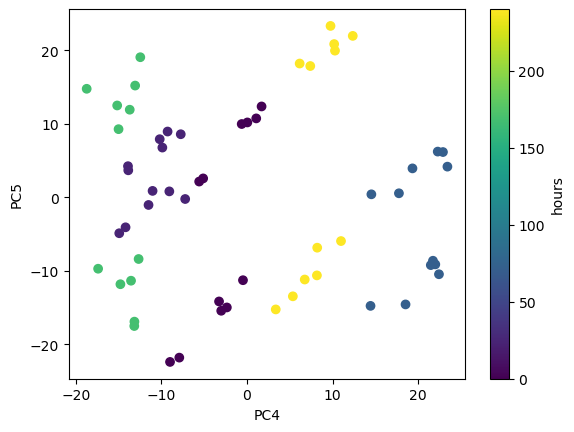

In [137]:
plt.scatter(meta_pca["PC4"], meta_pca["PC5"], c=meta_pca["hours"])
plt.colorbar(label="hours")
plt.xlabel("PC4")
plt.ylabel("PC5")
plt.show()

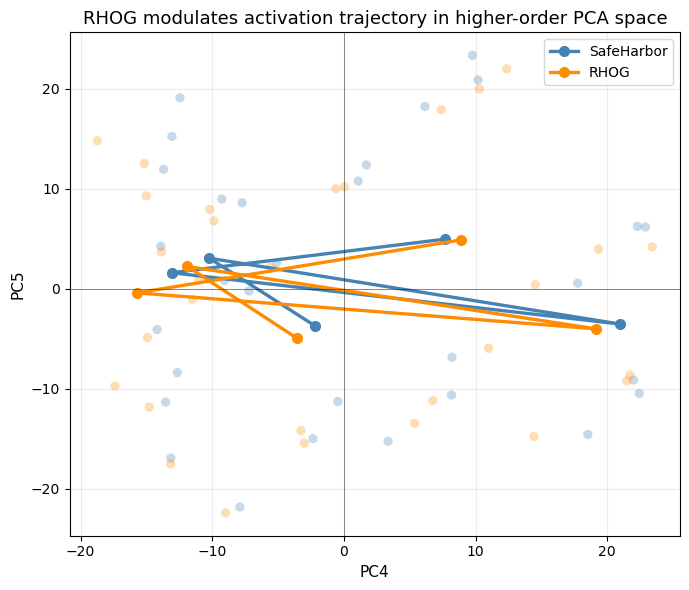

In [138]:
from pathlib import Path
import matplotlib.pyplot as plt

PCX, PCY = "PC4", "PC5"

fig, ax = plt.subplots(figsize=(7, 6))

colors = {"SafeHarbor": "steelblue", "RHOG": "darkorange"}

# Background samples
for guide in meta_pca["guide"].unique():
    m = meta_pca["guide"] == guide
    ax.scatter(
        meta_pca.loc[m, PCX],
        meta_pca.loc[m, PCY],
        s=45,
        alpha=0.3,
        color=colors[guide],
        edgecolor="none"
    )

# Time-ordered centroids
for guide in meta_pca["guide"].unique():
    centroids = (
        meta_pca[meta_pca["guide"] == guide]
        .groupby("hours")[[PCX, PCY]]
        .mean()
        .reset_index()
        .sort_values("hours")
    )

    ax.plot(
        centroids[PCX],
        centroids[PCY],
        "-o",
        linewidth=2.4,
        markersize=7,
        color=colors[guide],
        label=guide
    )

# Reference lines
ax.axvline(0, color="black", lw=0.6, alpha=0.5)
ax.axhline(0, color="black", lw=0.6, alpha=0.5)

ax.set_xlabel(f"{PCX}", fontsize=11)
ax.set_ylabel(f"{PCY}", fontsize=11)
ax.set_title("RHOG modulates activation trajectory in higher-order PCA space", fontsize=13)

ax.legend(frameon=True)
ax.grid(alpha=0.25)

fig.tight_layout()

# Save
outdir = Path("figures/fig4_RHOG_synthesis")
outdir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    outdir / "Fig4A_RHOG_vs_SH_PCA_PC4_PC5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

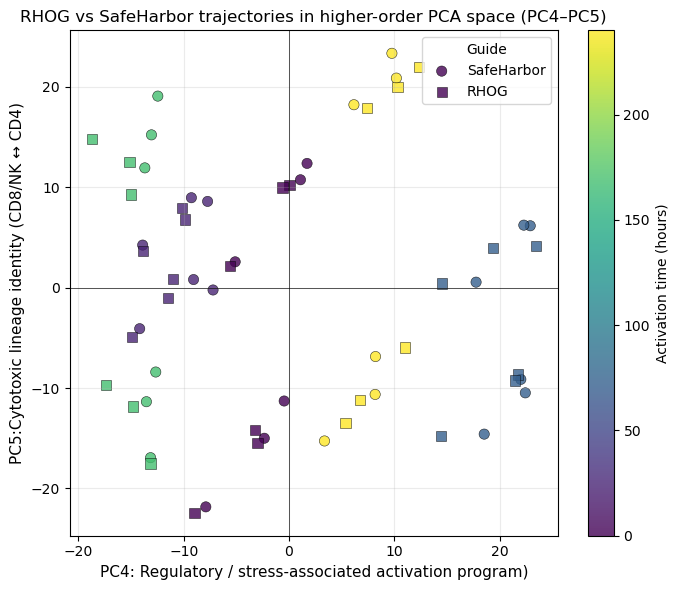

Saved: figures/fig4_RHOG_specific/Fig4A_PCA_PC4_PC5_lineage_trajectories.png


In [139]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

fig, ax = plt.subplots(figsize=(7, 6))

PCX, PCY = "PC4", "PC5"

# Marker mapping by guide
marker_map = {
    "SafeHarbor": "o",   # circle
    "RHOG": "s",         # square
}

# Continuous colormap for time
cmap = plt.cm.viridis
norm = plt.Normalize(meta_pca["hours"].min(), meta_pca["hours"].max())

# Plot each guide separately (for marker control)
for guide, marker in marker_map.items():
    m = meta_pca["guide"] == guide
    sc = ax.scatter(
        meta_pca.loc[m, PCX],
        meta_pca.loc[m, PCY],
        c=meta_pca.loc[m, "hours"],
        cmap=cmap,
        norm=norm,
        s=55,
        alpha=0.8,
        marker=marker,
        edgecolor="black",
        linewidth=0.4,
        label=guide,
    )

# Reference axes
ax.axvline(0, color="black", lw=0.7, alpha=0.65)
ax.axhline(0, color="black", lw=0.7, alpha=0.65)

# Labels
ax.set_xlabel("PC4: Regulatory / stress-associated activation program)", fontsize=11)
ax.set_ylabel("PC5:Cytotoxic lineage identity (CD8/NK ↔ CD4)", fontsize=11)
ax.set_title("RHOG vs SafeHarbor trajectories in higher-order PCA space (PC4–PC5)", fontsize=12)

# Legend (guide = shape)
ax.legend(title="Guide", frameon=True)

# Colorbar (time)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Activation time (hours)", fontsize=10)

ax.grid(alpha=0.25)
fig.tight_layout()



# -----------------------------
# Output location
# -----------------------------
OUTDIR = Path("figures/fig4_RHOG_specific")
OUTDIR.mkdir(parents=True, exist_ok=True)

OUTNAME = "Fig4A_PCA_PC4_PC5_lineage_trajectories.png"

# -----------------------------
# Save figure
# -----------------------------
outpath = OUTDIR / OUTNAME
fig.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)



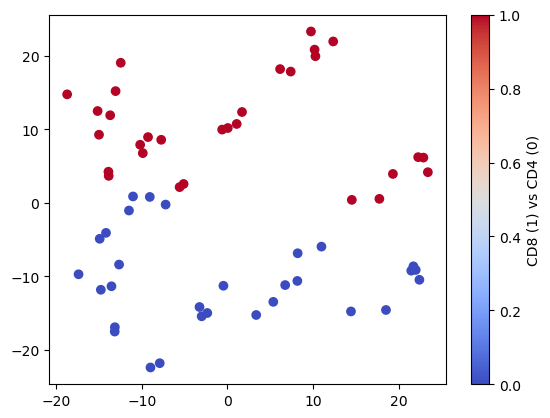

In [140]:
plt.scatter(meta_pca["PC4"], meta_pca["PC5"],
            c=meta_pca["cell_type"].map({"CD4":0, "CD8":1}),
            cmap="coolwarm")
plt.colorbar(label="CD8 (1) vs CD4 (0)")

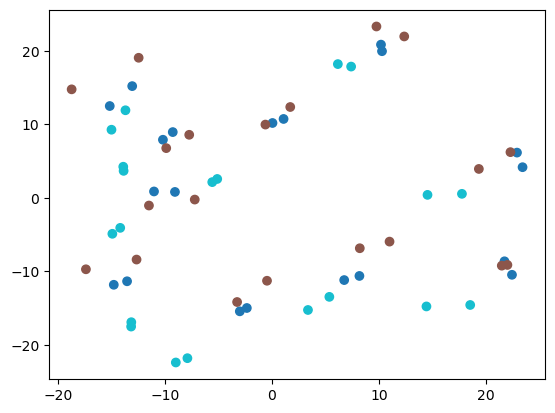

In [141]:
plt.scatter(meta_pca["PC4"], meta_pca["PC5"],
            c=meta_pca["donor"].astype("category").cat.codes,
            cmap="tab10")

In [142]:
import pandas as pd

# Load PCA loadings
loadings = pd.read_parquet("results/pca/pca_loadings.parquet")

# Sort by absolute contribution to PC4
pc4 = (
    loadings[["PC4"]]
    .assign(abs_PC4=lambda x: x["PC4"].abs())
    .sort_values("abs_PC4", ascending=False)
)

# Top drivers
pc4.head(30)

,PC4,abs_PC4
gene_symbol,,
FOXP3,0.090404,0.090404
CCL22,0.058195,0.058195
IL13,0.057007,0.057007
PPFIA4,0.054484,0.054484
ANGPTL4,0.049214,0.049214
GNLY,0.048872,0.048872
CD19,0.047743,0.047743
MYO7A,0.047492,0.047492
SCARA5,0.047272,0.047272


In [143]:
# meta_pca index should match expr columns
pc4_sorted = meta_pca["PC4"].sort_values(ascending=False)

top_samples = pc4_sorted.head(10).index
expr_symbol.loc["CD19", top_samples].sort_values(ascending=False)

sample_id
CART0077_RNAseq_NgsRun1_035    6.698478
CART0077_RNAseq_NgsRun1_034    6.526026
CART0077_RNAseq_NgsRun1_032    5.739141
CART0077_RNAseq_NgsRun1_029    5.681143
CART0077_RNAseq_NgsRun1_028    5.655607
CART0077_RNAseq_NgsRun1_033    5.483902
CART0077_RNAseq_NgsRun1_027    5.002192
CART0077_RNAseq_NgsRun1_031    4.258367
CART0077_RNAseq_NgsRun1_026    3.841958
CART0077_RNAseq_NgsRun1_025    3.164813
Name: CD19, dtype: float64

In [144]:
b_markers = ["CD19","MS4A1","CD79A","CD79B","CD74","HLA-DRA"]
expr_symbol.reindex(b_markers).loc[:, top_samples]

sample_id,CART0077_RNAseq_NgsRun1_032,CART0077_RNAseq_NgsRun1_031,CART0077_RNAseq_NgsRun1_025,CART0077_RNAseq_NgsRun1_033,CART0077_RNAseq_NgsRun1_027,CART0077_RNAseq_NgsRun1_026,CART0077_RNAseq_NgsRun1_028,CART0077_RNAseq_NgsRun1_034,CART0077_RNAseq_NgsRun1_029,CART0077_RNAseq_NgsRun1_035
symbol,,,,,,,,,,
CD19,5.739141,4.258367,3.164813,5.483902,5.002192,3.841958,5.655607,6.526026,5.681143,6.698478
MS4A1,0.000000,0.000000,0.000000,0.000000,0.034523,0.000000,0.000000,0.000000,0.000000,0.000000
CD79A,1.462352,0.979920,0.964487,1.482486,1.408805,1.209254,1.120792,1.790684,0.844775,1.556308
CD79B,2.591011,2.677708,2.789270,2.254118,2.484436,2.712572,2.665598,2.204076,2.754094,2.245244
CD74,6.614501,6.713452,6.387979,6.880204,6.738506,6.295180,6.545702,6.734519,6.391319,6.721396
HLA-DRA,5.310417,5.411078,4.780101,5.407210,5.085309,4.821580,4.742590,5.078811,4.588262,5.161675


In [145]:
genes = ["CD19", "MS4A1", "CD79A", "CD74", "HLA-DRA"]

expr_symbol.loc[genes].T.join(meta_pca[["cell_type","hours","guide"]]).groupby("cell_type")[genes].mean()

,CD19,MS4A1,CD79A,CD74,HLA-DRA
cell_type,,,,,
CD4,2.255296,0.004017,0.563566,6.817738,5.167084
CD8,2.486963,0.016559,0.800792,6.991574,5.502304


/var/folders/qx/x9q1q3ns1hl9156prswwpk5m0000gn/T/ipykernel_19251/2580061414.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


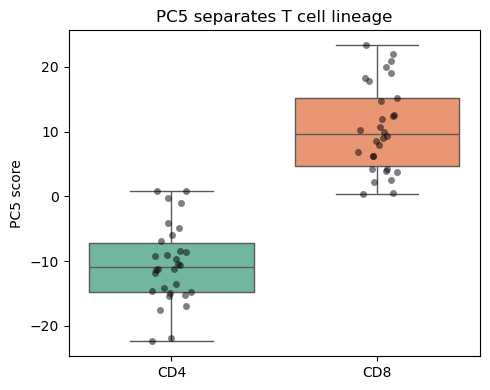

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.boxplot(
    data=meta_pca,
    x="cell_type",
    y="PC5",
    palette="Set2"
)
sns.stripplot(
    data=meta_pca,
    x="cell_type",
    y="PC5",
    color="black",
    alpha=0.5,
    jitter=True
)

plt.title("PC5 separates T cell lineage")
plt.ylabel("PC5 score")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [147]:
from scipy.stats import mannwhitneyu

cd4 = meta_pca.loc[meta_pca["cell_type"]=="CD4", "PC5"]
cd8 = meta_pca.loc[meta_pca["cell_type"]=="CD8", "PC5"]

u, p = mannwhitneyu(cd4, cd8)
p

np.float64(4.504322112705283e-11)

In [148]:
from pathlib import Path
import matplotlib.pyplot as plt

OUTDIR = Path("figures/figS_sanity_checks")
OUTDIR.mkdir(parents=True, exist_ok=True)

outpath = OUTDIR / "FigS1_PC5_separates_CD4_CD8.png"

fig = plt.gcf()  # or use your existing fig variable
fig.savefig(outpath, dpi=300, bbox_inches="tight", facecolor="white")
print("Saved:", outpath)

Saved: figures/figS_sanity_checks/FigS1_PC5_separates_CD4_CD8.png


<Figure size 640x480 with 0 Axes>

In [149]:
import pandas as pd

pca_loadings = pd.read_parquet("results/pca/pca_loadings.parquet")

pca_loadings.shape
pca_loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
gene_symbol,,,,,,,,,,,,,,,,,,,,
A1BG,-0.001120,-0.000782,0.002900,0.001312,0.001104,-0.000008,-0.001408,0.001798,-0.000535,-0.001934,0.002317,-0.003960,0.000237,0.001425,0.003236,-0.007573,0.005897,0.001736,0.004844,0.005190
A1BG-AS1,-0.003545,-0.003346,0.008035,0.004910,0.007800,-0.002671,-0.001997,0.001523,0.009768,-0.001992,-0.008486,0.001183,-0.002247,-0.004620,-0.001778,-0.025323,-0.007923,-0.010477,-0.008270,0.001833
A1CF,0.000237,-0.000059,0.000175,0.000065,0.000264,0.000086,0.000495,0.000265,-0.000016,0.000030,-0.000658,0.000171,-0.000206,0.001109,0.000616,-0.000421,0.000543,0.000040,-0.001470,0.001462
A2M,0.000565,0.000011,0.000310,0.000337,-0.000124,0.001135,0.000709,0.001366,0.000469,0.000696,-0.000134,-0.000475,0.000906,0.002760,0.000212,-0.000530,-0.001030,-0.001115,-0.002781,0.000550
A2M-AS1,-0.000570,-0.000147,0.001299,0.000010,-0.000066,0.004500,-0.001231,-0.003501,-0.001705,0.001027,-0.002425,-0.000028,-0.002114,0.002866,-0.000382,0.002946,-0.008618,-0.002930,-0.001582,0.000590


In [150]:
# pca_loadings: rows = genes, columns = PCs (PC1, PC2, ..., PC5)
pc = "PC5"

pc5 = pca_loadings[[pc]].copy()
pc5 = pc5.rename(columns={pc: "loading"})

# Top positive and negative genes
top_pos = pc5.sort_values("loading", ascending=False).head(20)
top_neg = pc5.sort_values("loading", ascending=True).head(20)

top_pos, top_neg

(              loading
 gene_symbol          
 CD8A         0.127502
 CD8B         0.123800
 LINC02446    0.120768
 PECAM1       0.080267
 TTC24        0.079336
 CD244        0.073641
 KLRD1        0.073441
 KLRC1        0.071789
 DBN1         0.071715
 NCAM1        0.071666
 ZNF683       0.071487
 STYK1        0.070318
 NKG7         0.069362
 GZMK         0.068118
 CTSW         0.067182
 ITGAD        0.066248
 KLRK1        0.065891
 LAG3         0.060877
 REG4         0.057719
 SLC17A9      0.056660,
               loading
 gene_symbol          
 CD4         -0.102668
 CYSLTR1     -0.078098
 IL17RB      -0.064589
 MAF         -0.058411
 CHDH        -0.053140
 IL13        -0.052243
 RMND5B      -0.049745
 PMCH        -0.048933
 CES4A       -0.048228
 FRY         -0.048107
 PTPRM       -0.047283
 RPS4Y1      -0.046982
 NPTX1       -0.046639
 MAN1C1      -0.046350
 TSHZ2       -0.046348
 ANKRD55     -0.046150
 IRX3        -0.046027
 ADCY1       -0.045771
 SLC12A7     -0.045297
 TNFRSF4  

In [151]:
import pandas as pd

mapping = pd.read_csv("data/processed/ensg_to_symbol.csv")
mapping.columns = mapping.columns.str.strip()
print(mapping.columns.tolist())
mapping.head()

['ensembl', 'symbol']


,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [152]:
print(type(mapping))
print(mapping.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
['ensembl', 'symbol']


In [153]:
print(type(pca_loadings))
print(pca_loadings.shape)
print(pca_loadings.columns[:10])
print("index sample:", pca_loadings.index[:5].tolist())

<class 'pandas.core.frame.DataFrame'>
(41250, 20)
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'], dtype='object')
index sample: ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1']


In [154]:
import pandas as pd

pc = "PC5"   # change as needed

pc_load = pca_loadings[[pc]].copy()

# Make ENSG a real column (whatever the index name is)
pc_load = pc_load.reset_index()
ensg_col = pc_load.columns[0]  # first column is the old index
pc_load = pc_load.rename(columns={ensg_col: "ensembl", pc: "loading"})

# Strip version suffixes like ENSG... .1 (safe even if none exist)
pc_load["ensembl"] = pc_load["ensembl"].astype(str).str.split(".").str[0]
mapping["ensembl"] = mapping["ensembl"].astype(str).str.split(".").str[0]

pc_load = pc_load.merge(mapping, on="ensembl", how="left")

pc_load.head()

,ensembl,loading,symbol
0,A1BG,0.001104,NaN
1,A1BG-AS1,0.007800,NaN
2,A1CF,0.000264,NaN
3,A2M,-0.000124,NaN
4,A2M-AS1,-0.000066,NaN


In [155]:
import pandas as pd

pc = "PC5"

# 1) Start from loadings for this PC
pc5_load = pca_loadings[[pc]].copy()

# 2) Convert index to a column named "ensembl" (works even if index has a name)
pc5_load = pc5_load.reset_index()
pc5_load = pc5_load.rename(columns={pc: "loading"})

# If the first column is not already called ensembl, rename it
first_col = pc5_load.columns[0]
if first_col != "ensembl":
    pc5_load = pc5_load.rename(columns={first_col: "ensembl"})

# 3) Strip ENSG version suffix if present (ENSGxxxx.y -> ENSGxxxx)
pc5_load["ensembl"] = pc5_load["ensembl"].astype(str).str.split(".").str[0]

# 4) Ensure mapping columns exist and are clean
# mapping should have columns: ['ensembl', 'symbol']
mapping = mapping.copy()
mapping["ensembl"] = mapping["ensembl"].astype(str).str.split(".").str[0]

# 5) Merge in symbols
pc5_load = pc5_load.merge(mapping, on="ensembl", how="left")

pc5_load.head(), pc5_load.columns

(    ensembl   loading symbol
 0      A1BG  0.001104    NaN
 1  A1BG-AS1  0.007800    NaN
 2      A1CF  0.000264    NaN
 3       A2M -0.000124    NaN
 4   A2M-AS1 -0.000066    NaN,
 Index(['ensembl', 'loading', 'symbol'], dtype='object'))

In [156]:
pc5_load["symbol"].notna().mean()

np.float64(0.0)

In [157]:
top_pos = pc5_load.sort_values("loading", ascending=False).head(30)
top_neg = pc5_load.sort_values("loading", ascending=True).head(30)

top_pos[["ensembl","symbol","loading"]]

,ensembl,symbol,loading
3899,CD8A,NaN,0.127502
3900,CD8B,NaN,0.123800
16012,LINC02446,NaN,0.120768
24265,PECAM1,NaN,0.080267
38554,TTC24,NaN,0.079336
3826,CD244,NaN,0.073641
13657,KLRD1,NaN,0.073441
13652,KLRC1,NaN,0.071789
6097,DBN1,NaN,0.071715
21369,NCAM1,NaN,0.071666


In [158]:
pc = "PC5"

pc5_load = pca_loadings[[pc]].copy().reset_index()
pc5_load = pc5_load.rename(columns={pc: "loading"})
first_col = pc5_load.columns[0]
if first_col != "ensembl":
    pc5_load = pc5_load.rename(columns={first_col: "ensembl"})

pc5_load["ensembl"] = pc5_load["ensembl"].astype(str).str.split(".").str[0]

mapping2 = mapping.copy()
mapping2["ensembl"] = mapping2["ensembl"].astype(str).str.split(".").str[0]

pc5_load = pc5_load.merge(mapping2, on="ensembl", how="left")

# drop unmapped for readability (optional)
pc5_load["symbol"] = pc5_load["symbol"].fillna(pc5_load["ensembl"])

top_pos = pc5_load.sort_values("loading", ascending=False).head(30)
top_neg = pc5_load.sort_values("loading", ascending=True).head(30)
top_abs = pc5_load.reindex(pc5_load["loading"].abs().sort_values(ascending=False).head(50).index)

top_pos[["symbol","loading"]]

,symbol,loading
3899,CD8A,0.127502
3900,CD8B,0.123800
16012,LINC02446,0.120768
24265,PECAM1,0.080267
38554,TTC24,0.079336
3826,CD244,0.073641
13657,KLRD1,0.073441
13652,KLRC1,0.071789
6097,DBN1,0.071715
21369,NCAM1,0.071666


In [159]:
top_neg[["symbol","loading"]]


,symbol,loading
3861,CD4,-0.102668
6017,CYSLTR1,-0.078098
12640,IL17RB,-0.064589
17148,MAF,-0.058411
4494,CHDH,-0.053140
12628,IL13,-0.052243
27261,RMND5B,-0.049745
24956,PMCH,-0.048933
4329,CES4A,-0.048228
9253,FRY,-0.048107


In [160]:
top_abs[["symbol","loading"]]

,symbol,loading
3899,CD8A,0.127502
3900,CD8B,0.123800
16012,LINC02446,0.120768
3861,CD4,-0.102668
24265,PECAM1,0.080267
38554,TTC24,0.079336
6017,CYSLTR1,-0.078098
3826,CD244,0.073641
13657,KLRD1,0.073441
13652,KLRC1,0.071789


In [161]:
import pandas as pd

pca_loadings = pd.read_parquet("results/pca/pca_loadings.parquet")
pca_loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
gene_symbol,,,,,,,,,,,,,,,,,,,,
A1BG,-0.001120,-0.000782,0.002900,0.001312,0.001104,-0.000008,-0.001408,0.001798,-0.000535,-0.001934,0.002317,-0.003960,0.000237,0.001425,0.003236,-0.007573,0.005897,0.001736,0.004844,0.005190
A1BG-AS1,-0.003545,-0.003346,0.008035,0.004910,0.007800,-0.002671,-0.001997,0.001523,0.009768,-0.001992,-0.008486,0.001183,-0.002247,-0.004620,-0.001778,-0.025323,-0.007923,-0.010477,-0.008270,0.001833
A1CF,0.000237,-0.000059,0.000175,0.000065,0.000264,0.000086,0.000495,0.000265,-0.000016,0.000030,-0.000658,0.000171,-0.000206,0.001109,0.000616,-0.000421,0.000543,0.000040,-0.001470,0.001462
A2M,0.000565,0.000011,0.000310,0.000337,-0.000124,0.001135,0.000709,0.001366,0.000469,0.000696,-0.000134,-0.000475,0.000906,0.002760,0.000212,-0.000530,-0.001030,-0.001115,-0.002781,0.000550
A2M-AS1,-0.000570,-0.000147,0.001299,0.000010,-0.000066,0.004500,-0.001231,-0.003501,-0.001705,0.001027,-0.002425,-0.000028,-0.002114,0.002866,-0.000382,0.002946,-0.008618,-0.002930,-0.001582,0.000590


In [162]:
pca_loadings = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)
pca_loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,quadrant_PC1_PC2
gene,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,9.366323e-05,-5.282017e-04,6.088233e-04,-3.385882e-04,1.808923e-04,4.860088e-04,-1.196203e-03,-3.756108e-05,-9.979868e-04,-5.844181e-04,...,3.536317e-03,3.163893e-04,1.667314e-03,-1.217134e-03,-2.964380e-03,6.528304e-04,-3.926019e-04,-6.542218e-04,-1.530320e-03,Q4
ENSG00000227232,-3.324999e-03,6.731644e-04,5.108593e-03,-5.471734e-03,-5.558026e-03,9.070120e-03,-1.617013e-02,3.802345e-03,-3.546346e-03,1.064187e-02,...,-2.880367e-03,4.094618e-03,-6.011375e-04,2.309274e-03,7.012333e-03,2.365731e-03,-4.389319e-03,-5.213923e-03,1.894618e-03,Q2
ENSG00000278267,-7.036649e-04,1.111626e-03,1.081793e-03,-3.061830e-03,9.131693e-05,2.191194e-03,-1.333419e-03,-2.701733e-04,-2.068966e-03,1.125666e-03,...,-2.441894e-03,-2.635515e-03,8.653626e-04,2.582577e-03,9.705423e-03,-6.766427e-03,1.576182e-03,-3.041267e-03,-1.353557e-03,Q2
ENSG00000243485,-6.616423e-05,-1.578408e-04,1.272980e-05,3.455076e-04,2.916554e-04,5.850734e-05,1.673697e-06,4.267931e-04,8.589290e-04,-5.087637e-04,...,1.382777e-03,-1.111069e-04,2.230550e-04,1.886302e-03,-1.648261e-03,9.649164e-04,6.785596e-05,-4.186622e-04,-3.946276e-03,Q3
ENSG00000284332,3.444683e-22,3.035688e-20,-6.395881e-19,3.802729e-17,2.707710e-17,-2.123324e-16,4.679518e-16,2.727930e-16,9.827153e-16,-7.346275e-15,...,-2.031949e-15,5.162920e-15,2.626342e-16,-2.274869e-15,2.652177e-15,1.151923e-15,-8.641983e-16,-3.298201e-15,-5.609388e-15,Q1


In [163]:
import pandas as pd

mapping = pd.read_csv(
    "data/processed/ensg_to_symbol.csv"
)

mapping.head()

,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [164]:
top_pos.to_csv("results/pca/PC5_top_positive_genes.csv")
top_neg.to_csv("results/pca/PC5_top_negative_genes.csv")

In [165]:
mapping.columns
mapping.head()

,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


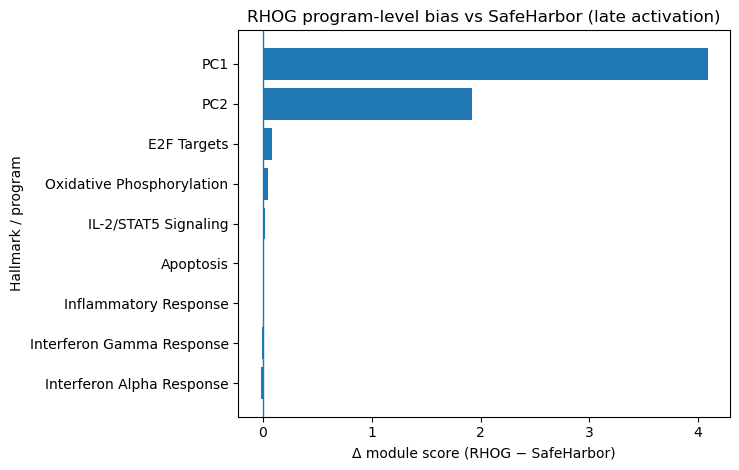

Saved: figures/fig4_rhog_specific/Fig4C_module_level_RHOG_bias_late.png


In [166]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- paths ----------
SCORES_PATH = Path("results/pathways/metadata_with_hallmark_scores.csv")
OUTDIR = Path("figures/fig4_rhog_specific")
OUTDIR.mkdir(parents=True, exist_ok=True)
OUTNAME = "Fig4C_module_level_RHOG_bias_late.png"

# ---------- load ----------
df = pd.read_csv(SCORES_PATH, index_col=0)

# Required columns
req = {"guide", "hours"}
missing = req - set(df.columns)
if missing:
    raise ValueError(f"metadata_with_hallmark_scores.csv missing columns: {missing}")

# ---------- choose program columns ----------
# Keep anything numeric that isn't metadata-ish
meta_like = {"GSM","title","cell_type","hours","guide","donor","sample_id"}
program_cols = [c for c in df.columns if c not in meta_like and pd.api.types.is_numeric_dtype(df[c])]

if len(program_cols) == 0:
    raise ValueError("No numeric program/module columns found. Check your hallmark score table.")

# ---------- define 'late' ----------
late_hours = [168, 240]  # adjust if you want include 72, etc.
df_late = df[df["hours"].isin(late_hours)].copy()

# ---------- compute delta ----------
means = (
    df_late
    .groupby("guide")[program_cols]
    .mean(numeric_only=True)
)

if not {"RHOG","SafeHarbor"}.issubset(means.index):
    raise ValueError(f"Expected guides RHOG and SafeHarbor, found: {list(means.index)}")

delta = (means.loc["RHOG"] - means.loc["SafeHarbor"]).sort_values()

# ---------- pick top programs for readability ----------
# Show top 6 down and top 6 up (edit numbers if you want)
k = 6
to_show = pd.concat([delta.head(k), delta.tail(k)])
to_show = to_show.sort_values()

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.barh(to_show.index, to_show.values)

ax.axvline(0, linewidth=1)
ax.set_title("RHOG program-level bias vs SafeHarbor (late activation)")
ax.set_xlabel("Δ module score (RHOG − SafeHarbor)")
ax.set_ylabel("Hallmark / program")

fig.tight_layout()

# ---------- save ----------
outpath = OUTDIR / OUTNAME
fig.savefig(outpath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", outpath)

In [167]:
pc = "PC1"   # or "PC2"

pc_load = (
    pca_loadings[[pc]]
    .reset_index()
    .rename(columns={"index": "ensembl", pc: "loading"})
)

pc_load["abs_loading"] = pc_load["loading"].abs()

top_pc_genes = pc_load.sort_values("abs_loading", ascending=False).head(200)

In [168]:
import pandas as pd

pc = "PC1"   # change as needed

pc_load = pca_loadings[[pc]].copy()

# Make ENSG a real column (whatever the index name is)
pc_load = pc_load.reset_index()
ensg_col = pc_load.columns[0]  # first column is the old index
pc_load = pc_load.rename(columns={ensg_col: "ensembl", pc: "loading"})

# Strip version suffixes like ENSG... .1 (safe even if none exist)
pc_load["ensembl"] = pc_load["ensembl"].astype(str).str.split(".").str[0]
mapping["ensembl"] = mapping["ensembl"].astype(str).str.split(".").str[0]

pc_load = pc_load.merge(mapping, on="ensembl", how="left")

pc_load.head()

,ensembl,loading,symbol
0,ENSG00000223972,9.366323e-05,DDX11L1
1,ENSG00000227232,-3.324999e-03,WASH7P
2,ENSG00000278267,-7.036649e-04,MIR6859-1
3,ENSG00000243485,-6.616423e-05,MIR1302-2HG
4,ENSG00000284332,3.444683e-22,MIR1302-2


In [169]:
import pandas as pd

pc = "PC1"

# 1) Start from loadings for this PC
pc1_load = pca_loadings[[pc]].copy()

# 2) Convert index to a column named "ensembl" (works even if index has a name)
pc1_load = pc1_load.reset_index()
pc1_load = pc1_load.rename(columns={pc: "loading"})

# If the first column is not already called ensembl, rename it
first_col = pc1_load.columns[0]
if first_col != "ensembl":
    pc1_load = pc1_load.rename(columns={first_col: "ensembl"})

# 3) Strip ENSG version suffix if present (ENSGxxxx.y -> ENSGxxxx)
pc1_load["ensembl"] = pc1_load["ensembl"].astype(str).str.split(".").str[0]

# 4) Ensure mapping columns exist and are clean
# mapping should have columns: ['ensembl', 'symbol']
mapping = mapping.copy()
mapping["ensembl"] = mapping["ensembl"].astype(str).str.split(".").str[0]

# 5) Merge in symbols
pc1_load = pc1_load.merge(mapping, on="ensembl", how="left")

pc1_load.head(), pc1_load.columns

(           ensembl       loading       symbol
 0  ENSG00000223972  9.366323e-05      DDX11L1
 1  ENSG00000227232 -3.324999e-03       WASH7P
 2  ENSG00000278267 -7.036649e-04    MIR6859-1
 3  ENSG00000243485 -6.616423e-05  MIR1302-2HG
 4  ENSG00000284332  3.444683e-22    MIR1302-2,
 Index(['ensembl', 'loading', 'symbol'], dtype='object'))

In [170]:
top_pos = pc1_load.sort_values("loading", ascending=False).head(30)
top_neg = pc1_load.sort_values("loading", ascending=True).head(30)

top_pos[["ensembl","symbol","loading"]]

,ensembl,symbol,loading
17389,ENSG00000164399,IL3,0.065809
58725,ENSG00000185686,PRAME,0.057727
47468,ENSG00000177455,CD19,0.055486
40239,ENSG00000204671,IL31,0.049034
11613,ENSG00000179348,GATA2,0.047174
39256,ENSG00000111537,IFNG,0.047119
17390,ENSG00000164400,CSF2,0.046530
1409,ENSG00000142949,PTPRF,0.046507
43965,ENSG00000185215,TNFAIP2,0.046306
13945,ENSG00000169429,CXCL8,0.045154


In [171]:
tpg = top_pc_genes.rename(columns={"gene": "symbol"}).copy()
tpg["symbol"] = tpg["symbol"].astype(str)

drivers = (
    tpg.merge(delta_expr, on="symbol", how="left")
       .dropna(subset=["delta_expr"])
)

drivers.sort_values(["abs_loading", "delta_expr"], ascending=[False, False]).head(20)

,symbol,loading,abs_loading,delta_expr


In [172]:
import pandas as pd
import numpy as np

# --- 0) start clean ---
tpg = top_pc_genes.copy()

# --- 1) standardize: create an 'ensembl' column no matter what ---
if "gene" in tpg.columns:
    tpg = tpg.rename(columns={"gene": "ensembl"})
elif "symbol" in tpg.columns:
    # in some of your earlier frames, 'symbol' was actually ENSG IDs
    tpg = tpg.rename(columns={"symbol": "ensembl"})
else:
    # sometimes ENSGs live in the index
    tpg = tpg.reset_index().rename(columns={"index": "ensembl"})

# make sure it's string + strip ENSG version suffix
tpg["ensembl"] = tpg["ensembl"].astype(str).str.split(".").str[0]

# --- 2) mapping ENSG -> symbol ---
mapping2 = mapping.copy()
mapping2["ensembl"] = mapping2["ensembl"].astype(str).str.split(".").str[0]

tpg = tpg.merge(mapping2, on="ensembl", how="left")

# drop unmapped ENSGs (optional but helps merges)
tpg = tpg.dropna(subset=["symbol"]).copy()

# --- 3) ensure abs_loading exists ---
if "abs_loading" not in tpg.columns:
    tpg["abs_loading"] = tpg["loading"].abs()

# --- 4) delta_expr must be keyed by gene SYMBOL ---
de = delta_expr.copy()
de["symbol"] = de["symbol"].astype(str)

drivers = (
    tpg.merge(de, on="symbol", how="left")
       .dropna(subset=["delta_expr"])
       .loc[:, ["ensembl", "symbol", "loading", "abs_loading", "delta_expr"]]
       .sort_values(["abs_loading", "delta_expr"], ascending=[False, False])
)

print("Mapped symbols fraction:", tpg["symbol"].notna().mean())
print("Drivers found:", drivers.shape)
drivers.head(25)

Mapped symbols fraction: 1.0
Drivers found: (198, 5)


,ensembl,symbol,loading,abs_loading,delta_expr
0,ENSG00000164399,IL3,0.065809,0.065809,0.212289
1,ENSG00000185686,PRAME,0.057727,0.057727,0.054258
2,ENSG00000177455,CD19,0.055486,0.055486,0.111972
3,ENSG00000204671,IL31,0.049034,0.049034,0.012932
4,ENSG00000179348,GATA2,0.047174,0.047174,0.035299
5,ENSG00000111537,IFNG,0.047119,0.047119,0.050216
6,ENSG00000164400,CSF2,0.046530,0.046530,0.034785
7,ENSG00000142949,PTPRF,0.046507,0.046507,0.157747
8,ENSG00000185215,TNFAIP2,0.046306,0.046306,0.235458
9,ENSG00000169429,CXCL8,0.045154,0.045154,-0.020767


In [173]:
print(tpg["symbol"].head())
print(de["symbol"].head())
print(tpg["symbol"].map(type).value_counts().head(3))
print(de["symbol"].map(type).value_counts().head(3))

0      IL3
1    PRAME
2     CD19
3     IL31
4    GATA2
Name: symbol, dtype: object
0        A1BG
1    A1BG-AS1
2        A1CF
3         A2M
4     A2M-AS1
Name: symbol, dtype: object
symbol
<class 'str'>    198
Name: count, dtype: int64
symbol
<class 'str'>    41250
Name: count, dtype: int64


In [174]:
late_hours = [168, 240]

expr_late = expr_symbol.loc[:, metadata["hours"].isin(late_hours)]

meta_late = metadata.loc[expr_late.columns]

mean_expr = (
    expr_late.T
    .assign(guide=meta_late["guide"].values)
    .groupby("guide")
    .mean()
)

delta_expr = mean_expr.loc["RHOG"] - mean_expr.loc["SafeHarbor"]
delta_expr = delta_expr.rename("delta_expr").reset_index()
delta_expr.columns = ["symbol", "delta_expr"]

In [175]:
# --- 1) sanity: what columns do we have? ---
print("top_pc_genes columns:", list(top_pc_genes.columns))
print("delta_expr columns:", list(delta_expr.columns))

# --- 2) ensure delta_expr has 'symbol' (it should already) ---
if "symbol" not in delta_expr.columns:
    raise ValueError("delta_expr must contain a 'symbol' column")

# --- 3) make a copy and create a 'symbol' column in top_pc_genes ---
tpg = top_pc_genes.copy()

# Common cases:
# - gene names stored in column 'gene_symbol'
# - gene names stored in column 'genes'



top_pc_genes columns: ['gene', 'loading', 'abs_loading']
delta_expr columns: ['symbol', 'delta_expr']


In [176]:
pca_loadings = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)

In [177]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Paths (adjust if yours differ)
# -------------------------
FIG4_DIR = Path("figures/fig4_rhog_specific")
FIG4_DIR.mkdir(parents=True, exist_ok=True)

PCA_LOADINGS_PATH = Path("results/pca/pca_loadings.parquet")   # or .csv if you use csv
MAPPING_PATH      = Path("data/processed/ensg_to_symbol.csv")  # your ENSG->symbol table
EXPR_SYMBOL_PATH  = Path("data/processed/expr_logcpm_symbol.parquet")  # symbol-collapsed matrix
META_PATH         = Path("data/processed/metadata_samples.csv")

# -------------------------
# Load tables
# -------------------------
pca_loadings = pd.read_parquet(PCA_LOADINGS_PATH)  # index: ENSG, columns: PC1..PC10
mapping = pd.read_csv(MAPPING_PATH)                # columns: ensembl, symbol

# Ensure clean ENSG IDs (remove version suffix)
mapping = mapping.copy()
mapping["ensembl"] = mapping["ensembl"].astype(str).str.split(".").str[0]

pca_loadings = pca_loadings.copy()
pca_loadings.index = pca_loadings.index.astype(str).str.split(".").str[0]

# Optional: load expression + metadata to compute RHOG - SafeHarbor delta at late timepoints
expr_symbol = pd.read_parquet(EXPR_SYMBOL_PATH)  # index: gene symbol, columns: sample IDs
metadata = pd.read_csv(META_PATH, index_col=0)   # index: sample IDs
# If your metadata index isn’t sample IDs, fix here:
# metadata.index should match expr_symbol.columns

# -------------------------
# Helper: build PC table
# -------------------------
def pc_gene_table(pc: str, top_n: int = 30, late_hours=(168, 240), add_delta=True):
    # Build loadings table with ENSG and symbols
    df = (
        pca_loadings[[pc]]
        .reset_index()
        .rename(columns={"index": "ensembl", pc: "loading"})
    )
    df["ensembl"] = df["ensembl"].astype(str).str.split(".").str[0]
    df = df.merge(mapping, on="ensembl", how="left")
    df["abs_loading"] = df["loading"].abs()

    # Top pos/neg by loading
    top_pos = df.sort_values("loading", ascending=False).head(top_n).copy()
    top_neg = df.sort_values("loading", ascending=True).head(top_n).copy()

    # Optional: add RHOG - SH delta expression at late timepoints
    if add_delta:
        # Subset late samples
        late_mask = metadata["hours"].isin(list(late_hours))
        late_samples = metadata.index[late_mask]

        expr_late = expr_symbol.loc[:, expr_symbol.columns.intersection(late_samples)]
        meta_late = metadata.loc[expr_late.columns]

        mean_expr = (
            expr_late.T
            .assign(guide=meta_late["guide"].values)
            .groupby("guide")
            .mean()
        )

        # delta per gene symbol (RHOG - SafeHarbor)
        delta_expr = (mean_expr.loc["RHOG"] - mean_expr.loc["SafeHarbor"]).rename("delta_expr")
        delta_expr = delta_expr.reset_index().rename(columns={"index": "symbol"})

        # Merge onto tables (match on symbol)
        for t in (top_pos, top_neg):
            t["symbol"] = t["symbol"].astype(str)
        delta_expr["symbol"] = delta_expr["symbol"].astype(str)

        top_pos = top_pos.merge(delta_expr, on="symbol", how="left")
        top_neg = top_neg.merge(delta_expr, on="symbol", how="left")

    # Keep a nice column order
    keep_cols = ["ensembl", "symbol", "loading", "abs_loading"]
    if add_delta:
        keep_cols += ["delta_expr"]

    return top_pos[keep_cols], top_neg[keep_cols]

# -------------------------
# Generate + save for PC1 and PC2
# -------------------------
for pc in ["PC1", "PC2"]:
    pos, neg = pc_gene_table(pc, top_n=30, late_hours=(168, 240), add_delta=True)

    pos.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_positive_loadings.csv", index=False)
    neg.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_negative_loadings.csv", index=False)

print("Saved CSV gene tables to:", FIG4_DIR)

KeyError: 'ensembl'

In [178]:
pc = "PC2"   # or "PC2"

pc_load = (
    pca_loadings[[pc]]
    .reset_index()
    .rename(columns={"index": "ensembl", pc: "loading"})
)

pc_load["abs_loading"] = pc_load["loading"].abs()

top_pc_genes = pc_load.sort_values("abs_loading", ascending=False).head(200)

In [179]:
import pandas as pd

pc = "PC1"   # change as needed

pc_load = pca_loadings[[pc]].copy()

# Make ENSG a real column (whatever the index name is)
pc_load = pc_load.reset_index()
ensg_col = pc_load.columns[0]  # first column is the old index
pc_load = pc_load.rename(columns={ensg_col: "ensembl", pc: "loading"})

# Strip version suffixes like ENSG... .1 (safe even if none exist)
pc_load["ensembl"] = pc_load["ensembl"].astype(str).str.split(".").str[0]
mapping["ensembl"] = mapping["ensembl"].astype(str).str.split(".").str[0]

pc_load = pc_load.merge(mapping, on="ensembl", how="left")

pc_load.head()

,ensembl,loading,symbol
0,A1BG,-0.001120,NaN
1,A1BG-AS1,-0.003545,NaN
2,A1CF,0.000237,NaN
3,A2M,0.000565,NaN
4,A2M-AS1,-0.000570,NaN


In [180]:
import pandas as pd

pc = "PC2"

# 1) Start from loadings for this PC
pc2_load = pca_loadings[[pc]].copy()

# 2) Convert index to a column named "ensembl" (works even if index has a name)
pc2_load = pc2_load.reset_index()
pc2_load = pc2_load.rename(columns={pc: "loading"})

# If the first column is not already called ensembl, rename it
first_col = pc2_load.columns[0]
if first_col != "ensembl":
    pc2_load = pc2_load.rename(columns={first_col: "ensembl"})

# 3) Strip ENSG version suffix if present (ENSGxxxx.y -> ENSGxxxx)
pc2_load["ensembl"] = pc2_load["ensembl"].astype(str).str.split(".").str[0]

# 4) Ensure mapping columns exist and are clean
# mapping should have columns: ['ensembl', 'symbol']
mapping = mapping.copy()
mapping["ensembl"] = mapping["ensembl"].astype(str).str.split(".").str[0]

# 5) Merge in symbols
pc2_load = pc2_load.merge(mapping, on="ensembl", how="left")

pc2_load.head(), pc2_load.columns

(    ensembl   loading symbol
 0      A1BG -0.000782    NaN
 1  A1BG-AS1 -0.003346    NaN
 2      A1CF -0.000059    NaN
 3       A2M  0.000011    NaN
 4   A2M-AS1 -0.000147    NaN,
 Index(['ensembl', 'loading', 'symbol'], dtype='object'))

In [181]:
top_pos = pc2_load.sort_values("loading", ascending=False).head(30)
top_neg = pc2_load.sort_values("loading", ascending=True).head(30)

top_pos[["ensembl","symbol","loading"]]

,ensembl,symbol,loading
3857,CD38,NaN,0.057995
11992,ID3,NaN,0.053577
37651,TNNT3,NaN,0.052780
3666,CCL22,NaN,0.048638
37023,TIE1,NaN,0.048610
6390,DENND6B,NaN,0.046348
7870,EPAS1,NaN,0.045808
9398,G0S2,NaN,0.045808
10056,GNLY,NaN,0.043894
11267,HMGB1P17,NaN,0.043346


In [182]:
# If gene is actually an index-like integer, recover real symbols from the index of the loadings table you used
# (If you built top_pc_genes from pc_load which had a 'symbol' column, re-build it from that source.)

# Quick check:
top_pc_genes.head(5)

,gene_symbol,loading,abs_loading
3857,CD38,0.057995,0.057995
11992,ID3,0.053577,0.053577
37651,TNNT3,0.052780,0.052780
24547,PI16,-0.052517,0.052517
26120,PTGDR2,-0.051028,0.051028


In [183]:
# What columns do we actually have?
print("df columns:", list(df.columns))

# Anything that looks like a score?
score_like = [c for c in df.columns if ("score" in c.lower()) or ("hallmark" in c.lower())]
print("\nScore-like columns:\n", score_like)

df columns: ['GSM', 'title', 'cell_type', 'hours', 'guide', 'donor', 'IL-2/STAT5 Signaling', 'Interferon Alpha Response', 'Interferon Gamma Response', 'Inflammatory Response', 'Apoptosis', 'E2F Targets', 'Oxidative Phosphorylation', 'PC1', 'PC2']

Score-like columns:
 []


In [184]:
from pathlib import Path
import matplotlib.pyplot as plt

late_hours = [168, 240]
df_late = df[df["hours"].isin(late_hours)].copy()

# Pick the columns that actually exist in df
candidate_program_cols = [
    "memory_score",
    "mem_minus_eff",
]

program_cols = [c for c in candidate_program_cols if c in df_late.columns]
print("Using program columns:", program_cols)

means = df_late.groupby("guide")[program_cols].mean()
delta = (means.loc["RHOG"] - means.loc["SafeHarbor"]).sort_values()

fig, ax = plt.subplots(figsize=(6,4))
colors = ["firebrick" if v > 0 else "steelblue" for v in delta.values]
ax.bar(delta.index, delta.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ score (RHOG − SafeHarbor)")
ax.set_title("RHOG-biased modulation of programs (late timepoints)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

OUTDIR = Path("figures/fig4_RHOG_specific")
OUTDIR.mkdir(parents=True, exist_ok=True)
outpath = OUTDIR / "Fig4C_program_bias_summary.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

print("Saved:", outpath)

Using program columns: []
Saved: figures/fig4_RHOG_specific/Fig4C_program_bias_summary.png


In [185]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- Define which columns are the "programs" (Hallmarks) in your df ---
program_cols = [
    "IL-2/STAT5 Signaling",
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
    "E2F Targets",
    "Oxidative Phosphorylation",
]

late_hours = [168, 240]

df_late = df[df["hours"].isin(late_hours)].copy()

# safety check
missing = [c for c in program_cols if c not in df_late.columns]
if missing:
    raise ValueError(f"Missing program columns in df: {missing}")

# mean program scores by guide
means = df_late.groupby("guide")[program_cols].mean()

# RHOG - SafeHarbor
delta = (means.loc["RHOG"] - means.loc["SafeHarbor"]).sort_values()

# --- Plot ---
fig, ax = plt.subplots(figsize=(7.5, 4.2))
colors = ["firebrick" if v > 0 else "steelblue" for v in delta.values]
ax.bar(delta.index, delta.values, color=colors)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ Hallmark score (RHOG − SafeHarbor)")
ax.set_title("Fig 4C — RHOG bias in program activity at late activation (168–240h)")
ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()

# --- Save ---
OUTDIR = Path("figures/fig4_RHOG_specific")
OUTDIR.mkdir(parents=True, exist_ok=True)

outpath = OUTDIR / "Fig4C_program_bias_late_168_240h.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

print("Saved:", outpath)

Saved: figures/fig4_RHOG_specific/Fig4C_program_bias_late_168_240h.png


In [186]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

program_cols = [
    "IL-2/STAT5 Signaling",
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
    "E2F Targets",
    "Oxidative Phosphorylation",
]
late_hours = [168, 240]

df_late = df[df["hours"].isin(late_hours)].copy()

# donor-averaged per guide first
donor_means = (
    df_late
    .groupby(["guide", "donor"])[program_cols]
    .mean()
    .reset_index()
)

# compute delta per donor (RHOG - SafeHarbor)
wide = donor_means.pivot(index="donor", columns="guide", values=program_cols)
delta_by_donor = wide.xs("RHOG", level=1, axis=1) - wide.xs("SafeHarbor", level=1, axis=1)

delta = delta_by_donor.mean().sort_values()
se = (delta_by_donor.std(ddof=1) / np.sqrt(delta_by_donor.shape[0])).reindex(delta.index)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
colors = ["firebrick" if v > 0 else "steelblue" for v in delta.values]
ax.bar(delta.index, delta.values, yerr=se.values, capsize=3, color=colors)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ Hallmark score (RHOG − SafeHarbor)")
ax.set_title("Fig 4C — RHOG program bias at late activation (168–240h), donor-averaged")
ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()

OUTDIR = Path("figures/fig4_RHOG_specific")
OUTDIR.mkdir(parents=True, exist_ok=True)
outpath = OUTDIR / "Fig4C_program_bias_late_168_240h_donorSE.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

print("Saved:", outpath)

Saved: figures/fig4_RHOG_specific/Fig4C_program_bias_late_168_240h_donorSE.png


In [195]:
print("pca_loadings index name:", pca_loadings.index.name)
print("first 5 index values:", list(pca_loadings.index[:5]))

pca_loadings index name: gene_symbol
first 5 index values: ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1']


In [196]:
import numpy as np
import pandas as pd

def pc_gene_table_symbol(
    pc: str,
    top_n: int = 30,
    late_hours=(168, 240),
    add_delta=True
):
    # pca_loadings index = gene symbols
    df = (
        pca_loadings[[pc]]
        .reset_index()
        .rename(columns={"gene_symbol": "symbol", pc: "loading"})
    )
    df["abs_loading"] = df["loading"].abs()

    if add_delta:
        # expr_symbol index = gene symbols
        late_mask = metadata["hours"].isin(late_hours)
        expr_late = expr_symbol.loc[:, late_mask]
        meta_late = metadata.loc[expr_late.columns]

        mean_expr = (
            expr_late.T
            .assign(guide=meta_late["guide"].values)
            .groupby("guide")
            .mean()
        )

        delta_expr = (mean_expr.loc["RHOG"] - mean_expr.loc["SafeHarbor"]).rename("delta_expr")
        delta_expr = delta_expr.reset_index().rename(columns={"index": "symbol"})

        # ensure strings
        df["symbol"] = df["symbol"].astype(str)
        delta_expr["symbol"] = delta_expr["symbol"].astype(str)

        df = df.merge(delta_expr, on="symbol", how="left")

    top_pos = df.sort_values("loading", ascending=False).head(top_n)
    top_neg = df.sort_values("loading", ascending=True).head(top_n)

    return top_pos, top_neg

In [197]:
from pathlib import Path

FIG4_DIR = Path("figures/fig4_rhog_specific")
FIG4_DIR.mkdir(parents=True, exist_ok=True)

for pc in ["PC1", "PC2"]:
    pos, neg = pc_gene_table_symbol(pc, top_n=30, late_hours=(168, 240), add_delta=True)

    pos.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_positive_loadings.csv", index=False)
    neg.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_negative_loadings.csv", index=False)

    display(pos.head(10))
    display(neg.head(10))

,symbol,loading,abs_loading,delta_expr
12686,IL3,0.067070,0.067070,0.212289
25543,PRAME,0.058820,0.058820,0.054258
3809,CD19,0.056515,0.056515,0.111972
12687,IL31,0.049957,0.049957,0.012932
9633,GATA2,0.048068,0.048068,0.035299
12081,IFNG,0.048011,0.048011,0.050216
5514,CSF2,0.047405,0.047405,0.034785
26229,PTPRF,0.047397,0.047397,0.157747
37585,TNFAIP2,0.047165,0.047165,0.235458
5800,CXCL8,0.046044,0.046044,-0.020767


,symbol,loading,abs_loading,delta_expr
2796,C11orf21,-0.037985,0.037985,-0.230956
38472,TSPAN32,-0.036272,0.036272,-0.246735
26682,RASGRP2,-0.035291,0.035291,-0.117915
36617,TC2N,-0.034497,0.034497,-0.298025
370,ADA2,-0.034084,0.034084,-0.267190
24627,PIK3IP1,-0.033515,0.033515,-0.201680
35297,SORL1,-0.033447,0.033447,-0.085933
3757,CCR5,-0.033126,0.033126,-0.260834
26426,RAB37,-0.032306,0.032306,-0.088527
19939,MMP25,-0.031421,0.031421,-0.101086


,symbol,loading,abs_loading,delta_expr
3857,CD38,0.057995,0.057995,-0.045946
11992,ID3,0.053577,0.053577,0.232382
37651,TNNT3,0.052780,0.052780,-0.103920
3666,CCL22,0.048638,0.048638,0.675200
37023,TIE1,0.048610,0.048610,-0.090150
6390,DENND6B,0.046348,0.046348,0.070758
7870,EPAS1,0.045808,0.045808,0.016206
9398,G0S2,0.045808,0.045808,0.269245
10056,GNLY,0.043894,0.043894,-0.222555
11267,HMGB1P17,0.043346,0.043346,-0.050147


,symbol,loading,abs_loading,delta_expr
24547,PI16,-0.052517,0.052517,-0.060123
26120,PTGDR2,-0.051028,0.051028,-0.015942
3757,CCR5,-0.047549,0.047549,-0.260834
12712,IL7R,-0.044935,0.044935,-0.178594
3754,CCR2,-0.043771,0.043771,-0.275843
40947,ZNF683,-0.042518,0.042518,0.005166
17008,LTB,-0.041529,0.041529,-0.212458
26621,RAP1GAP2,-0.038621,0.038621,-0.082439
4928,CMPK2,-0.038188,0.038188,-0.019024
13557,KLF2,-0.037962,0.037962,-0.113374


In [198]:
def pc_gene_table_symbol(
    pc: str,
    top_n: int = 30,
    late_hours=(168, 240),
    add_delta=True
):
    # 1) Build base table from PCA loadings (symbols already!)
    df = (
        pca_loadings[[pc]]
        .reset_index()
        .rename(columns={"gene_symbol": "symbol", pc: "loading"})
    )
    df["abs_loading"] = df["loading"].abs()

    # 2) Optionally add RHOG − SafeHarbor delta expression
    if add_delta:
        late_mask = metadata["hours"].isin(late_hours)
        expr_late = expr_symbol.loc[:, late_mask]
        meta_late = metadata.loc[expr_late.columns]

        mean_expr = (
            expr_late.T
            .assign(guide=meta_late["guide"].values)
            .groupby("guide")
            .mean()
        )

        delta_expr = (
            mean_expr.loc["RHOG"] - mean_expr.loc["SafeHarbor"]
        ).rename("delta_expr").reset_index().rename(columns={"index": "symbol"})

        df = df.merge(delta_expr, on="symbol", how="left")

    # 3) Rank
    top_pos = df.sort_values("loading", ascending=False).head(top_n)
    top_neg = df.sort_values("loading", ascending=True).head(top_n)

    return top_pos, top_neg

In [199]:
from pathlib import Path

FIG4_DIR = Path("figures/fig4_rhog_specific")
FIG4_DIR.mkdir(parents=True, exist_ok=True)

for pc in ["PC1", "PC2"]:
    pos, neg = pc_gene_table_symbol(pc, top_n=30, late_hours=(168, 240), add_delta=True)

    pos.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_positive_loadings.csv", index=False)
    neg.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_negative_loadings.csv", index=False)

    display(pos.head(10))
    display(neg.head(10))

,symbol,loading,abs_loading,delta_expr
12686,IL3,0.067070,0.067070,0.212289
25543,PRAME,0.058820,0.058820,0.054258
3809,CD19,0.056515,0.056515,0.111972
12687,IL31,0.049957,0.049957,0.012932
9633,GATA2,0.048068,0.048068,0.035299
12081,IFNG,0.048011,0.048011,0.050216
5514,CSF2,0.047405,0.047405,0.034785
26229,PTPRF,0.047397,0.047397,0.157747
37585,TNFAIP2,0.047165,0.047165,0.235458
5800,CXCL8,0.046044,0.046044,-0.020767


,symbol,loading,abs_loading,delta_expr
2796,C11orf21,-0.037985,0.037985,-0.230956
38472,TSPAN32,-0.036272,0.036272,-0.246735
26682,RASGRP2,-0.035291,0.035291,-0.117915
36617,TC2N,-0.034497,0.034497,-0.298025
370,ADA2,-0.034084,0.034084,-0.267190
24627,PIK3IP1,-0.033515,0.033515,-0.201680
35297,SORL1,-0.033447,0.033447,-0.085933
3757,CCR5,-0.033126,0.033126,-0.260834
26426,RAB37,-0.032306,0.032306,-0.088527
19939,MMP25,-0.031421,0.031421,-0.101086


,symbol,loading,abs_loading,delta_expr
3857,CD38,0.057995,0.057995,-0.045946
11992,ID3,0.053577,0.053577,0.232382
37651,TNNT3,0.052780,0.052780,-0.103920
3666,CCL22,0.048638,0.048638,0.675200
37023,TIE1,0.048610,0.048610,-0.090150
6390,DENND6B,0.046348,0.046348,0.070758
7870,EPAS1,0.045808,0.045808,0.016206
9398,G0S2,0.045808,0.045808,0.269245
10056,GNLY,0.043894,0.043894,-0.222555
11267,HMGB1P17,0.043346,0.043346,-0.050147


,symbol,loading,abs_loading,delta_expr
24547,PI16,-0.052517,0.052517,-0.060123
26120,PTGDR2,-0.051028,0.051028,-0.015942
3757,CCR5,-0.047549,0.047549,-0.260834
12712,IL7R,-0.044935,0.044935,-0.178594
3754,CCR2,-0.043771,0.043771,-0.275843
40947,ZNF683,-0.042518,0.042518,0.005166
17008,LTB,-0.041529,0.041529,-0.212458
26621,RAP1GAP2,-0.038621,0.038621,-0.082439
4928,CMPK2,-0.038188,0.038188,-0.019024
13557,KLF2,-0.037962,0.037962,-0.113374


In [204]:
pos_pc1, neg_pc1 = pc_gene_table_symbol("PC1")
pos_pc2, neg_pc2 = pc_gene_table_symbol("PC2")
  return df, top_pos, top_neg
df_pc1, pos_pc1, neg_pc1 = pc_gene_table_symbol("PC1")

IndentationError: unexpected indent (933398386.py, line 3)

In [205]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG4_DIR = Path("figures/fig4_rhog_specific")
FIG4_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# REQUIREMENTS (these must already exist in your notebook)
# -------------------------
# pca_loadings: DataFrame index = gene symbols (you confirmed: index name 'gene_symbol', values like 'A1BG')
#               columns include 'PC1','PC2',...
# expr_symbol:  DataFrame rows = gene symbols, columns = sample_id
# metadata:     DataFrame indexed by sample_id, includes columns: 'hours','guide'
# -------------------------

def compute_delta_expr(expr_symbol, metadata, late_hours=(168, 240)):
    """Mean(RHOG) - Mean(SafeHarbor) using late timepoints only."""
    late_mask = metadata["hours"].isin(late_hours)
    sample_ids = metadata.index[late_mask]

    expr_late = expr_symbol.loc[:, sample_ids]
    meta_late = metadata.loc[sample_ids]

    mean_expr = (
        expr_late.T
        .assign(guide=meta_late["guide"].values)
        .groupby("guide")
        .mean()
    )
    delta = (mean_expr.loc["RHOG"] - mean_expr.loc["SafeHarbor"]).rename("delta_expr")
    delta = delta.reset_index().rename(columns={"index": "symbol"})
    return delta

def pc_gene_table_symbol(pca_loadings, pc="PC1", top_n=25, delta_expr=None):
    """Return top pos/neg loading tables for a PC (symbols already)."""
    df = (
        pca_loadings[[pc]]
        .reset_index()
        .rename(columns={pca_loadings.index.name or "index": "symbol", pc: "loading"})
    )
    df["abs_loading"] = df["loading"].abs()

    if delta_expr is not None:
        df = df.merge(delta_expr, on="symbol", how="left")

    top_pos = df.sort_values("loading", ascending=False).head(top_n).copy()
    top_neg = df.sort_values("loading", ascending=True).head(top_n).copy()
    return top_pos, top_neg

def render_table_png(df, out_png, title, max_rows=25, float_fmt="{:.3f}"):
    """Render a dataframe as a clean PNG table."""
    df_plot = df.copy().head(max_rows)

    # Format numeric columns for readability
    for c in df_plot.columns:
        if np.issubdtype(df_plot[c].dtype, np.number):
            df_plot[c] = df_plot[c].map(lambda x: float_fmt.format(x) if pd.notnull(x) else "")

    fig, ax = plt.subplots(figsize=(10, 0.35 * (len(df_plot) + 3)))
    ax.axis("off")
    ax.set_title(title, fontsize=12, pad=10)

    table = ax.table(
        cellText=df_plot.values,
        colLabels=df_plot.columns,
        loc="center",
        cellLoc="left",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.2)

    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("Saved:", out_png)

# -------------------------
# 1) Compute late-timepoint delta expression (RHOG - SafeHarbor)
# -------------------------
delta_expr = compute_delta_expr(expr_symbol, metadata, late_hours=(168, 240))

# -------------------------
# 2) Build PC1/PC2 tables and save
# -------------------------
for pc in ["PC1", "PC2"]:
    top_pos, top_neg = pc_gene_table_symbol(
        pca_loadings=pca_loadings,
        pc=pc,
        top_n=25,
        delta_expr=delta_expr
    )

    # Save CSVs (authoritative)
    top_pos.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_positive_loadings_with_delta.csv", index=False)
    top_neg.to_csv(FIG4_DIR / f"Fig4C_{pc}_top_negative_loadings_with_delta.csv", index=False)

    # Save PNG tables (drop into PPTX)
    render_table_png(
        top_pos[["symbol", "loading", "abs_loading", "delta_expr"]],
        FIG4_DIR / f"Fig4C_{pc}_top_positive_loadings_table.png",
        title=f"{pc} — Top positive loading genes (with late RHOG–SH Δexpr)"
    )
    render_table_png(
        top_neg[["symbol", "loading", "abs_loading", "delta_expr"]],
        FIG4_DIR / f"Fig4C_{pc}_top_negative_loadings_table.png",
        title=f"{pc} — Top negative loading genes (with late RHOG–SH Δexpr)"
    )

Saved: figures/fig4_rhog_specific/Fig4C_PC1_top_positive_loadings_table.png
Saved: figures/fig4_rhog_specific/Fig4C_PC1_top_negative_loadings_table.png
Saved: figures/fig4_rhog_specific/Fig4C_PC2_top_positive_loadings_table.png
Saved: figures/fig4_rhog_specific/Fig4C_PC2_top_negative_loadings_table.png


In [206]:
import pandas as pd
from pathlib import Path

# --- late activation window ---
late_hours = [168, 240]

expr_late = expr_symbol.loc[:, metadata["hours"].isin(late_hours)]
meta_late = metadata.loc[expr_late.columns]

mean_expr = (
    expr_late.T
    .assign(guide=meta_late["guide"].values)
    .groupby("guide")
    .mean()
)

delta_expr = (
    mean_expr.loc["RHOG"] - mean_expr.loc["SafeHarbor"]
).rename("delta_expr").reset_index()

delta_expr.columns = ["symbol", "delta_expr"]

In [207]:
def pc_gene_table(pc, top_n=30):
    df = (
        pca_loadings[[pc]]
        .rename(columns={pc: "loading"})
        .reset_index()
        .rename(columns={"gene_symbol": "symbol"})
    )

    df["abs_loading"] = df["loading"].abs()

    df = df.merge(delta_expr, on="symbol", how="left").dropna(subset=["delta_expr"])

    pos = (
        df[df["loading"] > 0]
        .sort_values("abs_loading", ascending=False)
        .head(top_n)[["symbol", "delta_expr"]]
    )

    neg = (
        df[df["loading"] < 0]
        .sort_values("abs_loading", ascending=False)
        .head(top_n)[["symbol", "delta_expr"]]
    )

    return pos, neg

In [208]:
FIG4_DIR = Path("figures/fig4_rhog_specific")
FIG4_DIR.mkdir(parents=True, exist_ok=True)

for pc in ["PC1", "PC2"]:
    pos, neg = pc_gene_table(pc, top_n=25)

    pos.to_csv(FIG4_DIR / f"Fig4C_{pc}_positive_genes.csv", index=False)
    neg.to_csv(FIG4_DIR / f"Fig4C_{pc}_negative_genes.csv", index=False)

    print(f"Saved {pc} tables")

Saved PC1 tables
Saved PC2 tables


In [209]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIG4_DIR = Path("figures/fig4_rhog_specific")
FIG4_DIR.mkdir(parents=True, exist_ok=True)

def save_side_by_side_tables(pc: str, n_rows: int = 25):
    pos_path = FIG4_DIR / f"Fig4C_{pc}_positive_genes.csv"
    neg_path = FIG4_DIR / f"Fig4C_{pc}_negative_genes.csv"

    pos = pd.read_csv(pos_path).head(n_rows).copy()
    neg = pd.read_csv(neg_path).head(n_rows).copy()

    # Pretty formatting
    pos["delta_expr"] = pos["delta_expr"].map(lambda x: f"{x:+.3f}")
    neg["delta_expr"] = neg["delta_expr"].map(lambda x: f"{x:+.3f}")

    # --- Build figure ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 0.45*n_rows + 2))
    for ax in axes:
        ax.axis("off")

    

    # Left table (positive loadings)
    tbl1 = axes[0].table(
        cellText=pos.values,
        colLabels=["Gene", "Δexpr (RHOG − SH)"],
        loc="center",
        cellLoc="left",
    )
    axes[0].set_title(f"{pc}: Positive-loading genes", fontsize=12, pad=12)

    # Right table (negative loadings)
    tbl2 = axes[1].table(
        cellText=neg.values,
        colLabels=["Gene", "Δexpr (RHOG − SH)"],
        loc="center",
        cellLoc="left",
    )
    axes[1].set_title(f"{pc}: Negative-loading genes", fontsize=12, pad=12)

    # Style: font + row height
    for tbl in [tbl1, tbl2]:
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1, 1.2)

    fig.suptitle(
        f"Fig 4C — {pc} axis drivers and RHOG late-activation bias (168–240h)",
        fontsize=13,
        y=0.98
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    out_png = FIG4_DIR / f"Fig4C_{pc}_gene_tables.png"
    fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("Saved:", out_png)

# --- Generate both ---
save_side_by_side_tables("PC1", n_rows=25)
save_side_by_side_tables("PC2", n_rows=25)

Saved: figures/fig4_rhog_specific/Fig4C_PC1_gene_tables.png
Saved: figures/fig4_rhog_specific/Fig4C_PC2_gene_tables.png


In [223]:
def save_combined_pc1_pc2(n_rows: int = 20):
    pcs = ["PC1", "PC2"]
    dfs = {}
    for pc in pcs:
        pos = pd.read_csv(FIG4_DIR / f"Fig4C_{pc}_positive_genes.csv").head(n_rows).copy()
        neg = pd.read_csv(FIG4_DIR / f"Fig4C_{pc}_negative_genes.csv").head(n_rows).copy()
        pos["delta_expr"] = pos["delta_expr"].map(lambda x: f"{x:+.3f}")
        neg["delta_expr"] = neg["delta_expr"].map(lambda x: f"{x:+.3f}")
        dfs[(pc, "pos")] = pos
        dfs[(pc, "neg")] = neg

    fig, axes = plt.subplots(2, 2, figsize=(12, 0.45*n_rows*2 + 3))
    for ax in axes.ravel():
        ax.axis("off")

    for i, pc in enumerate(pcs):
        for j, side in enumerate(["pos", "neg"]):
            df = dfs[(pc, side)]
            title = f"{pc}: {'Positive' if side=='pos' else 'Negative'}-loading genes"
            
            tbl = axes[i, j].table(
                cellText=df.values,
                colLabels=["Gene", "Δexpr (RHOG − SH)"],
                loc="upper center",   # 👈 key change
                cellLoc="left",
            )
            axes[i, j].set_title(title, fontsize=11, pad=2)
            tbl.auto_set_font_size(False)
            tbl.set_fontsize(9)
            tbl.scale(1, 1.2)

            tbl.auto_set_font_size(False)
            tbl.set_fontsize(9)
            tbl.scale(1, 1.15)

    fig.suptitle(
        "Fig 4C — PC axis drivers + RHOG late-activation bias (168–240h)",
        fontsize=14,
        y=0.98
    )

    # after all plotting 
    fig.subplots_adjust(hspace=0.12, wspace=0.25)

    fig.savefig(outpath, dpi=300, bbox_inches="tight")

    out_png = FIG4_DIR / "Fig4C_PC1_PC2_gene_tables.png"
    fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("Saved:", out_png)

save_combined_pc1_pc2(n_rows=20)

Saved: figures/fig4_rhog_specific/Fig4C_PC1_PC2_gene_tables.png
